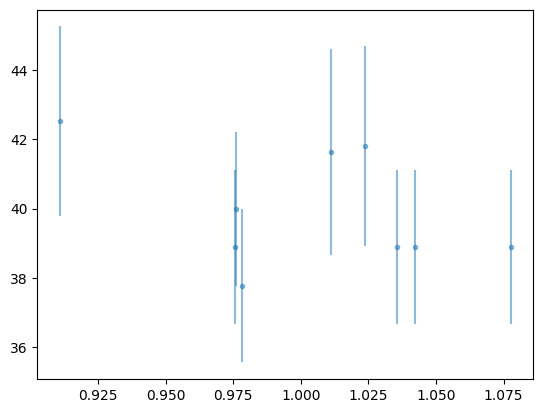

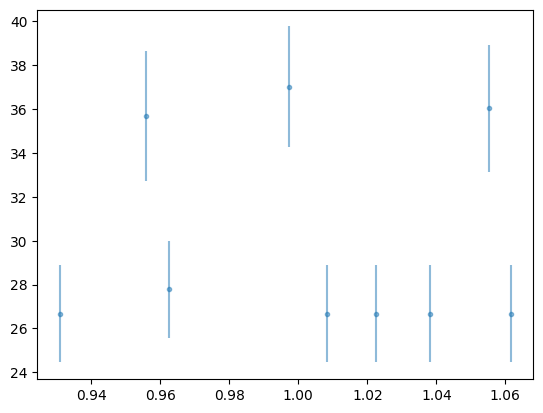

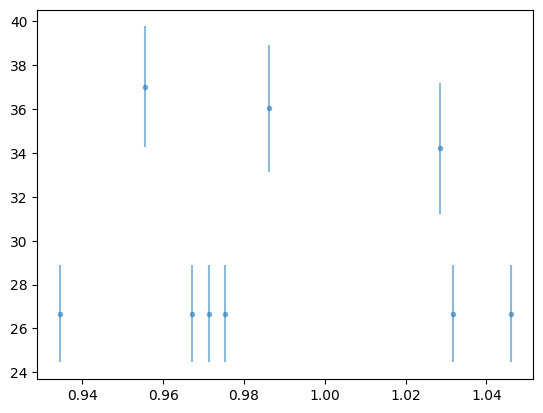

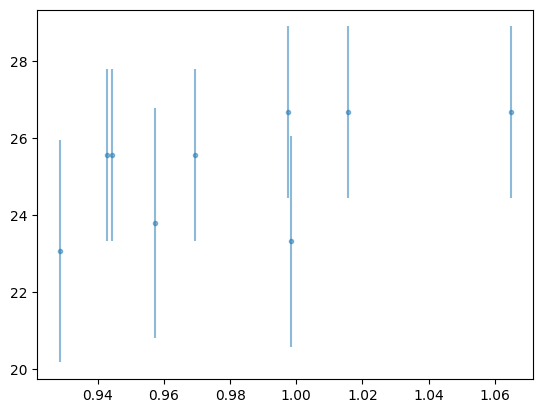

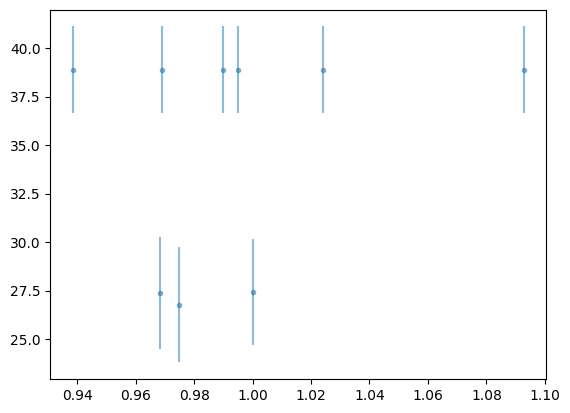

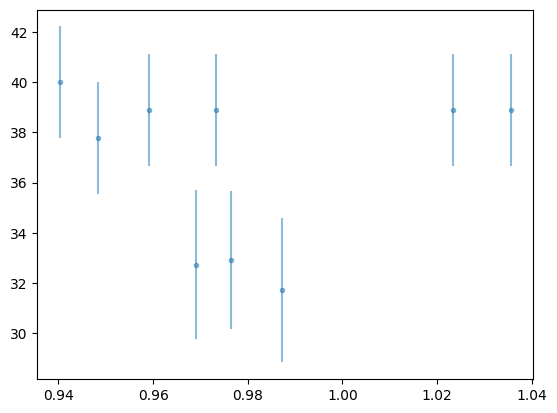

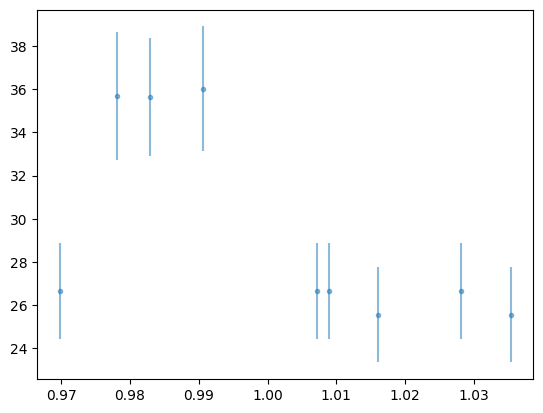

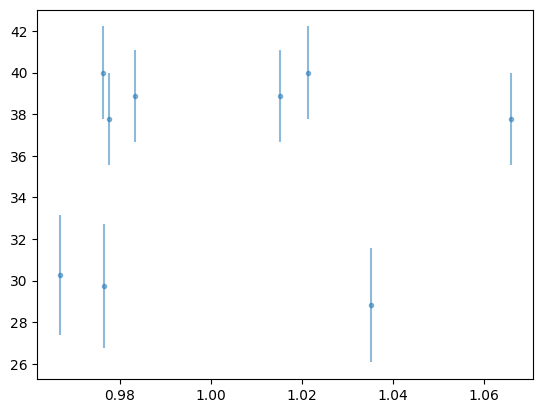

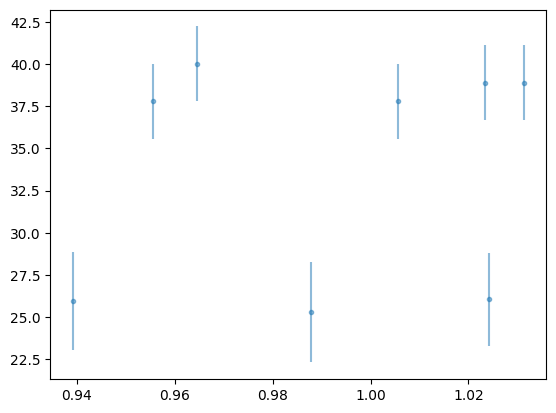

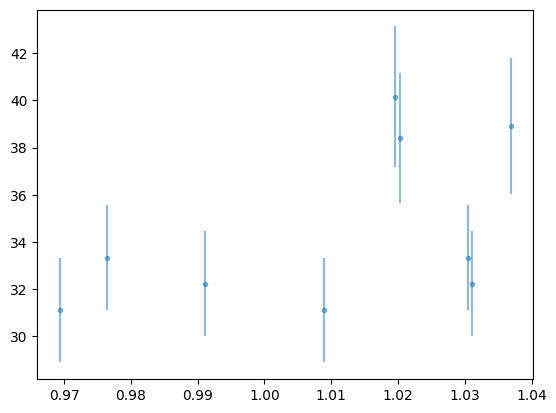

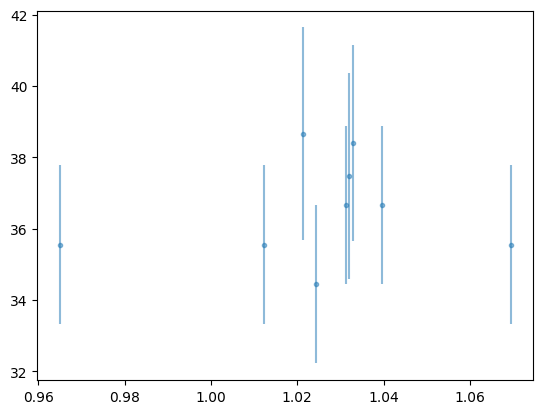

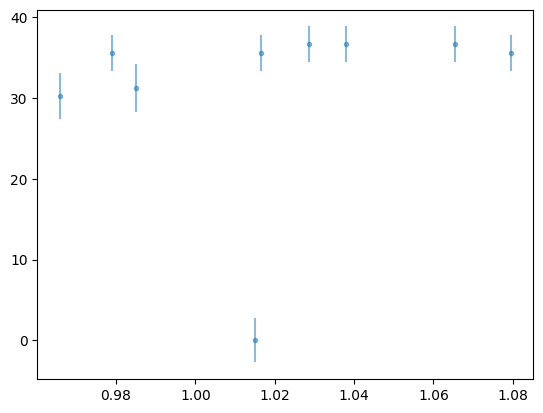

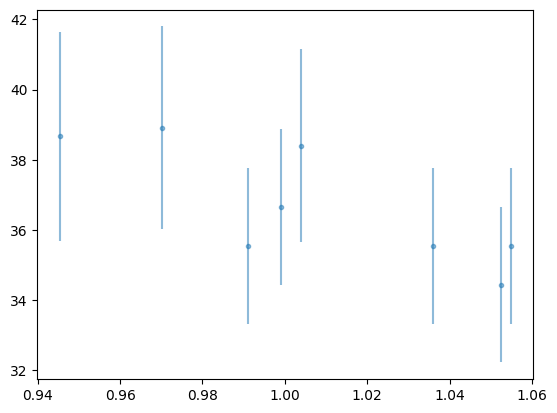

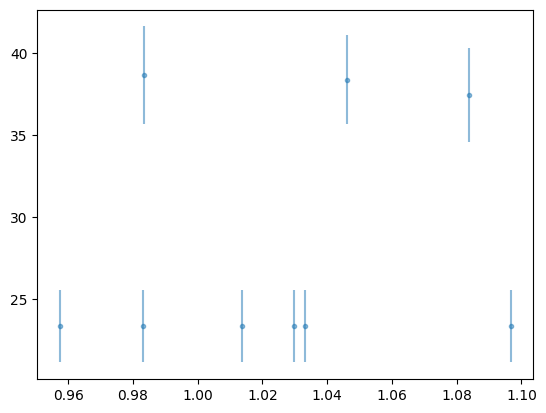

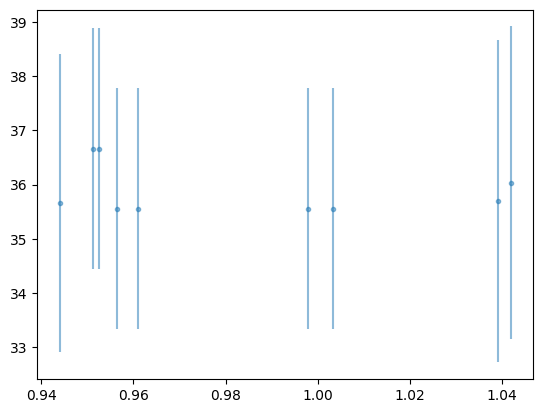

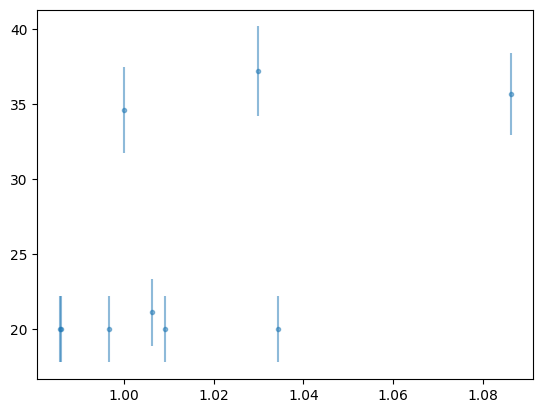

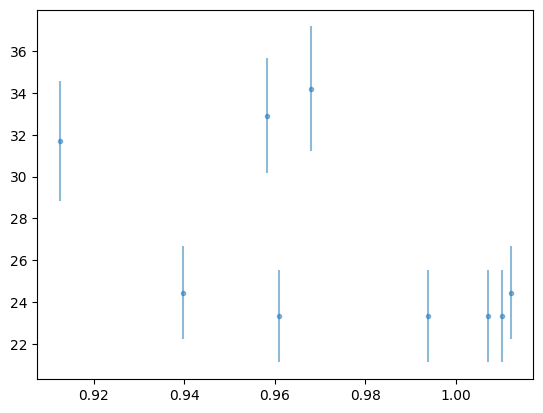

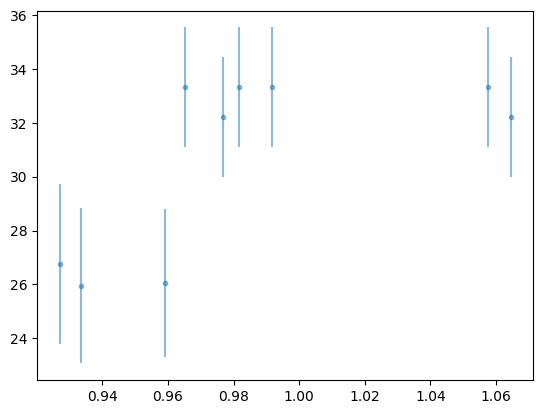

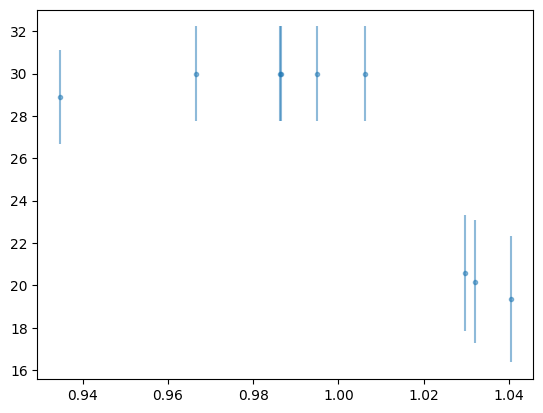

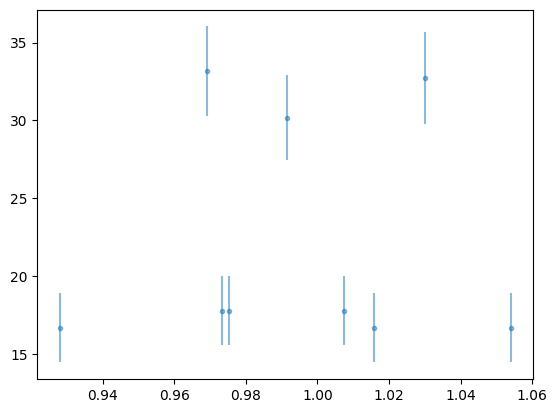

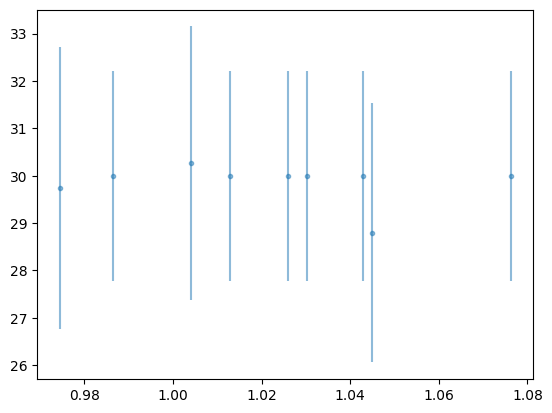

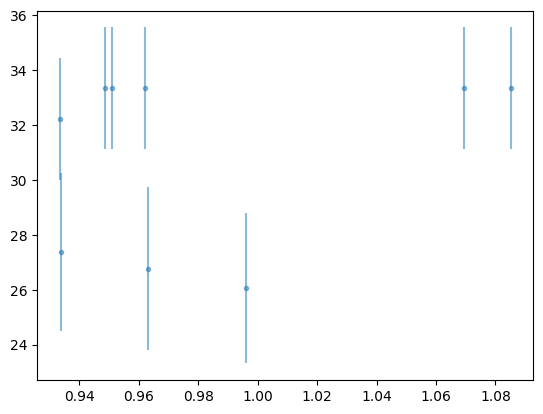

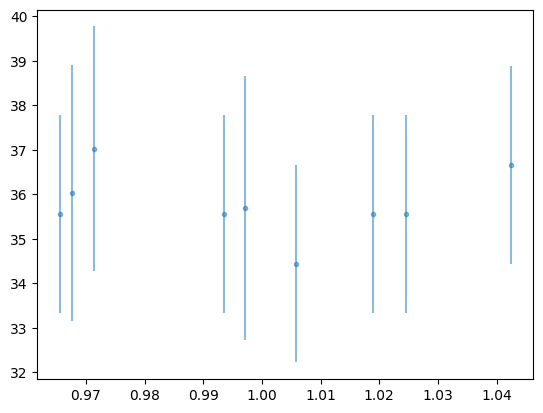

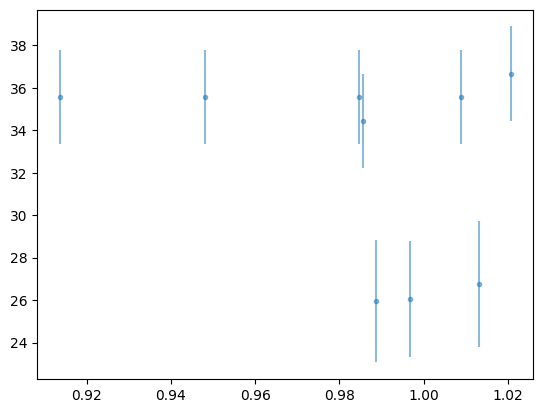

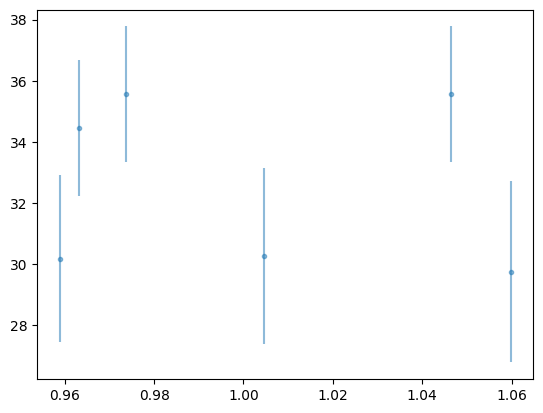

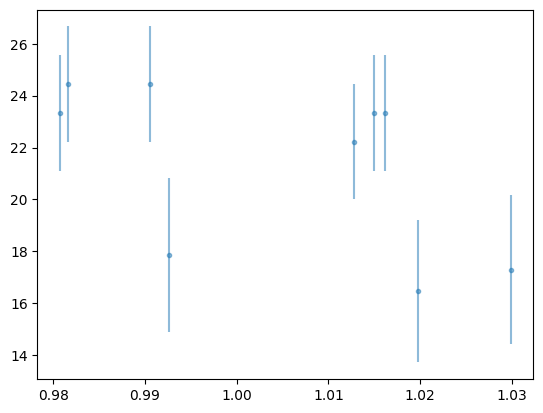

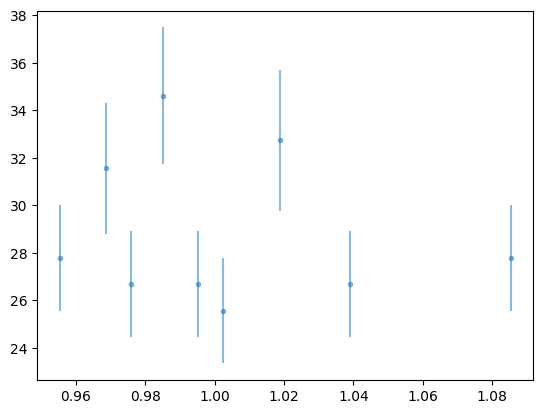

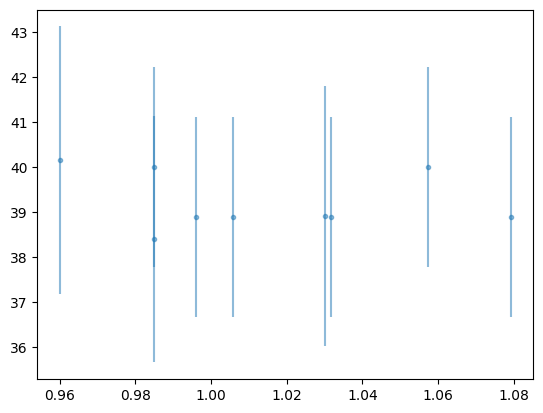

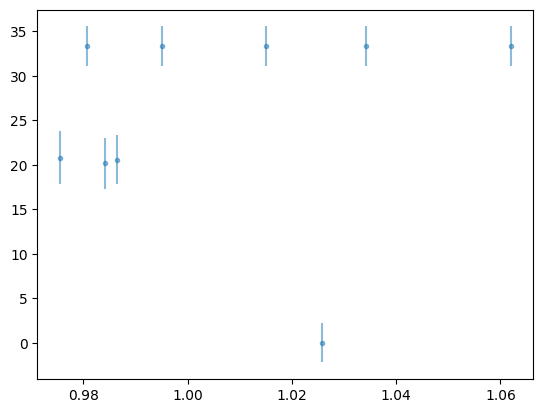

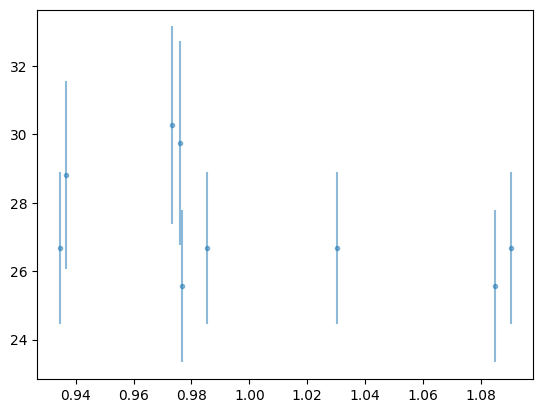

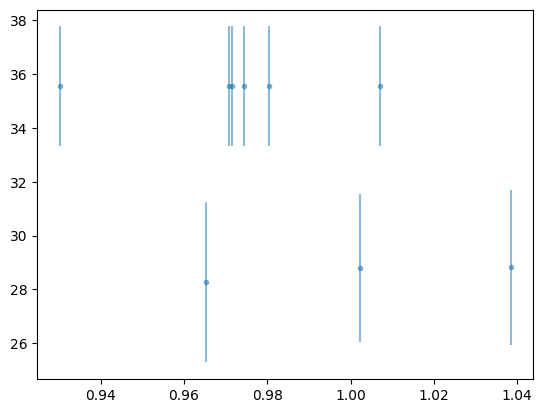

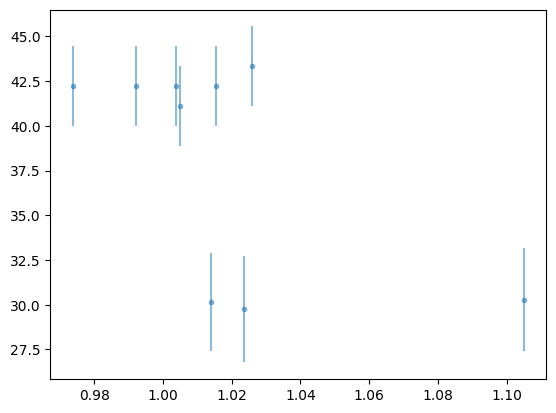

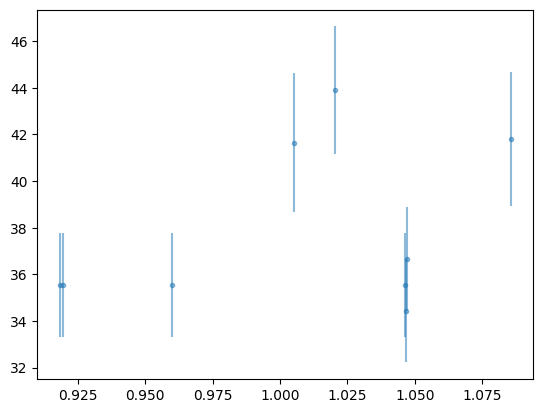

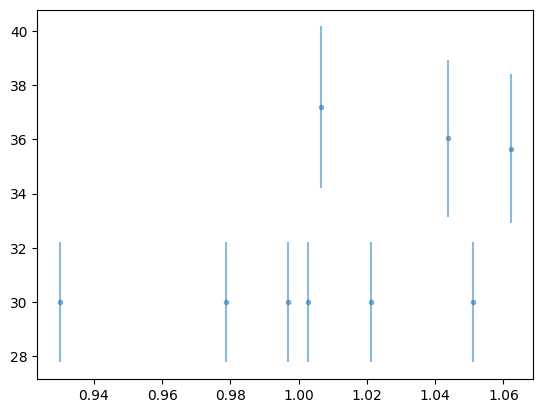

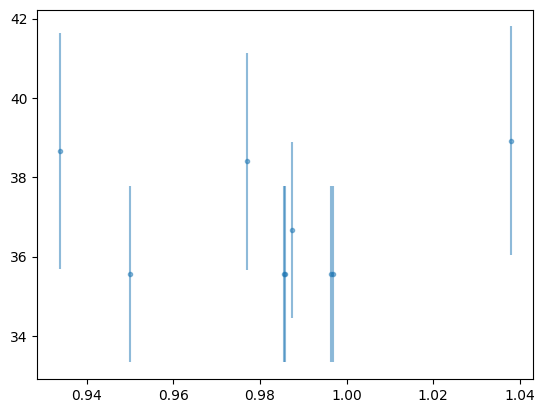

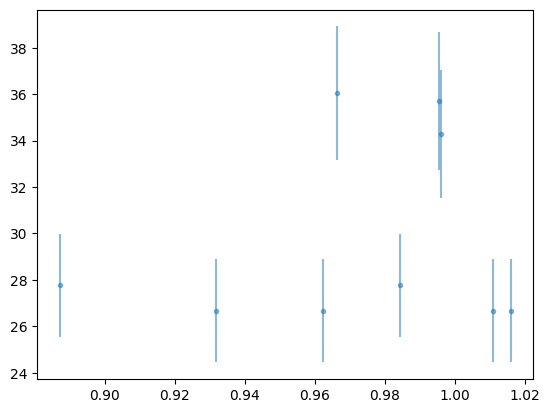

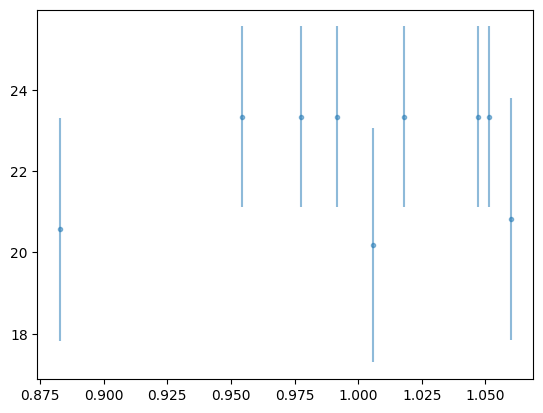

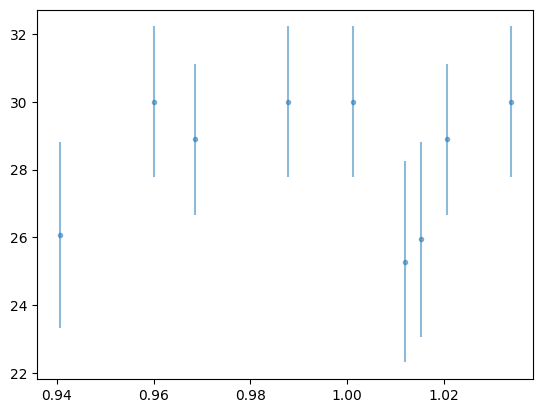

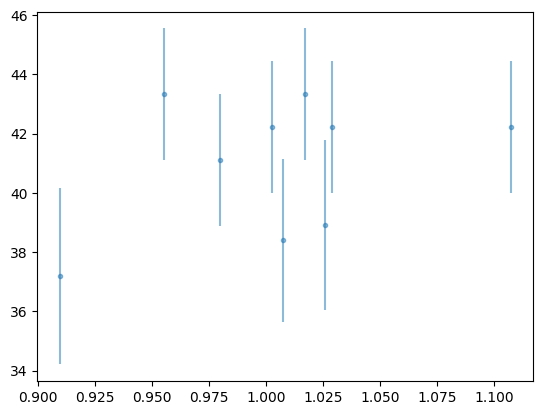

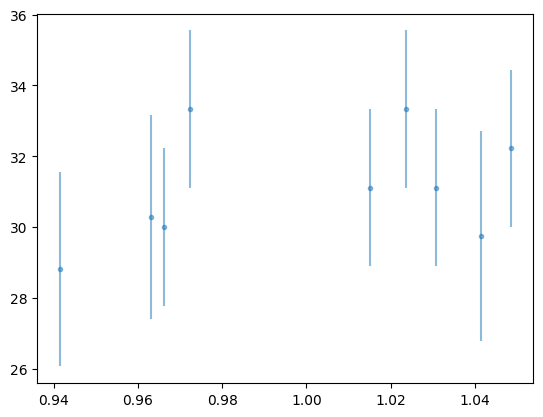

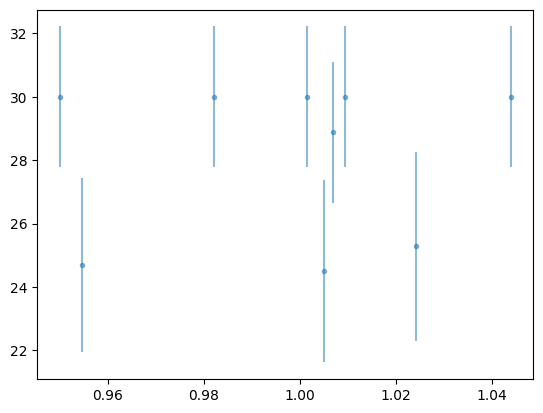

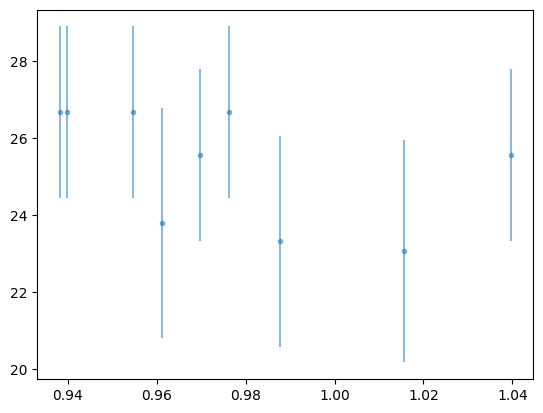

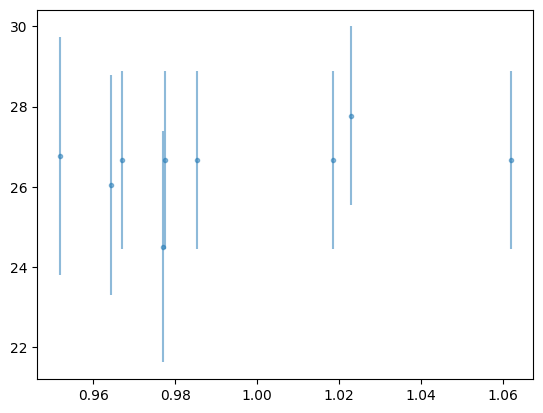

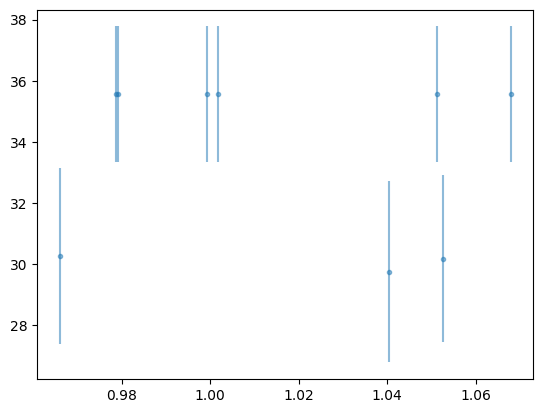

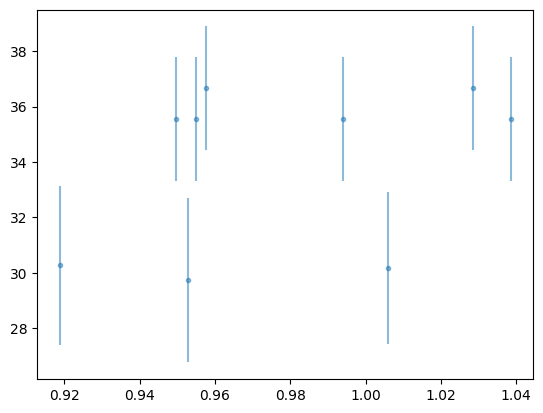

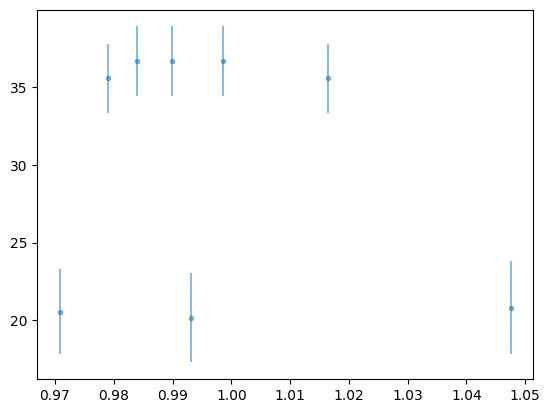

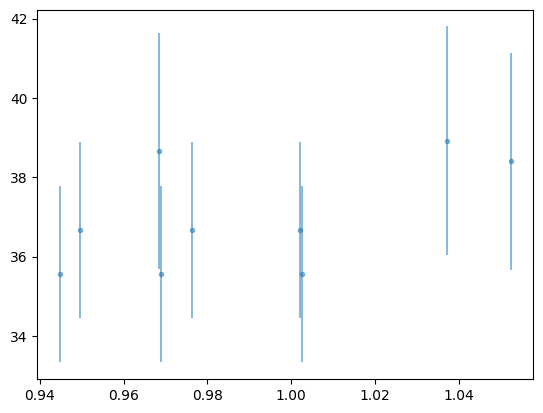

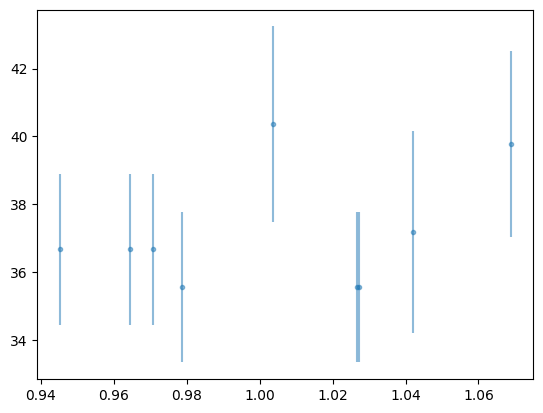

In [36]:
xml_path = "/data_storage/gu08wuvu/datasets/bentum2023/downloaded/XML_INFO/PP3/blocks.xml"

# import xml parser

import xml.etree.ElementTree as ET
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt



for xml_path in glob.glob(os.path.join("/data_storage/gu08wuvu/datasets/bentum2023/downloaded/XML_INFO", "**", "blocks.xml")):
    duration, error, exp, nf = [], [], [], []
    tree = ET.parse(xml_path)
    for elem in tree.iter():
        if elem.tag == "exp_type":
            exp.append(elem.text)
        if elem.tag == "duration_sample":
            duration.append(int(elem.text))
        if elem.tag == "sample_inacc":
            error.append(int(elem.text))
        if elem.tag == "fids":
            nf.append(elem.text.count(",")+1)

    df = pd.DataFrame({"exp": exp, "duration": duration, "error": error, "num_files": nf})
    df = df[df["num_files"] == 1]
    df["ppm"] = (df["error"]*1e6/df["duration"])
    df["ppm_error"] = (1e6/df["duration"])

    df = df[df["ppm"] < 200]

    plt.errorbar(
        np.random.normal(1, 0.04, size=len(df["ppm"])),
        df["ppm"],
        yerr=df["ppm_error"]*2,
        alpha=0.5,
        #color="black",
        fmt="o",
        markersize=3,
    )
    plt.show()

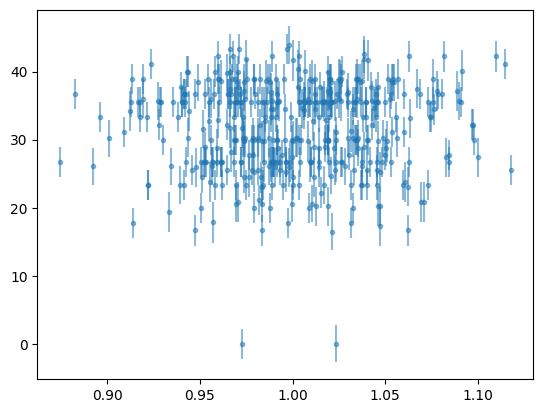

In [37]:
xml_path = "/data_storage/gu08wuvu/datasets/bentum2023/downloaded/XML_INFO/PP3/blocks.xml"

# import xml parser

import xml.etree.ElementTree as ET
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

duration, error, exp, nf = [], [], [], []


for xml_path in glob.glob(os.path.join("/data_storage/gu08wuvu/datasets/bentum2023/downloaded/XML_INFO", "**", "blocks.xml")):
    tree = ET.parse(xml_path)
    for elem in tree.iter():
        if elem.tag == "exp_type":
            exp.append(elem.text)
        if elem.tag == "duration_sample":
            duration.append(int(elem.text))
        if elem.tag == "sample_inacc":
            error.append(int(elem.text))
        if elem.tag == "fids":
            nf.append(elem.text.count(",")+1)

df = pd.DataFrame({"exp": exp, "duration": duration, "error": error, "num_files": nf})
df = df[df["num_files"] == 1]
df["ppm"] = (df["error"]*1e6/df["duration"])
df["ppm_error"] = (1e6/df["duration"])

df = df[df["ppm"] < 200]

plt.errorbar(
    np.random.normal(1, 0.04, size=len(df["ppm"])),
    df["ppm"],
    yerr=df["ppm_error"]*2,
    alpha=0.5,
    #color="black",
    fmt="o",
    markersize=3,
)
plt.show()

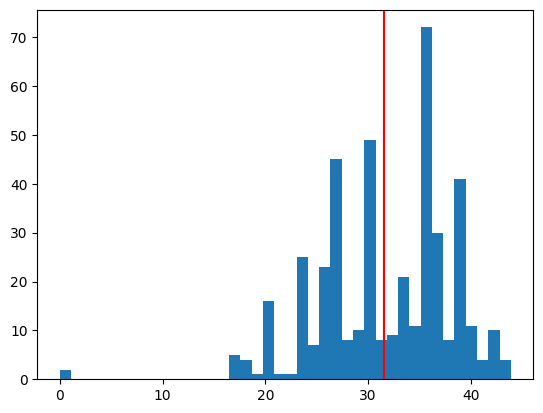

In [38]:
plt.hist(df["ppm"], bins=40)
plt.axvline(x=df["ppm"].mean(), color="red", label="mean")

{'whiskers': [<matplotlib.lines.Line2D at 0x718877402ad0>,
 'caps': [<matplotlib.lines.Line2D at 0x718877402890>,
 'boxes': [<matplotlib.lines.Line2D at 0x7188758be830>],
 'medians': [<matplotlib.lines.Line2D at 0x718877400f40>],
 'fliers': [<matplotlib.lines.Line2D at 0x718877402500>],
 'means': []}

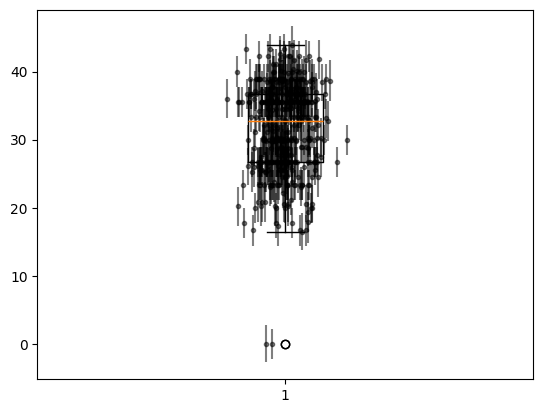

In [41]:
import numpy as np


plt.errorbar(
    np.random.normal(1, 0.04, size=len(df["ppm"])),
    df["ppm"],
    yerr=df["ppm_error"]*2,
    alpha=0.5,
    color="black",
    fmt="o",
    markersize=3,
)

plt.boxplot(df["ppm"])
